In [1]:
from astropy.io import fits
from spectral_cube import SpectralCube
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

In [2]:
name_fits_file = 'observations/new_cube30Dor_SOAR_invertedY_NEWWAVELENGTH.fits'   
#name_fits_file = 'Halpha_slab_6566_6571.fits'  
cont_map =  'Halpha_continuum_map.fits'

In [3]:
hdul_cube = fits.open(name_fits_file)
hdul_cube.info()
data_cube = hdul_cube[0].data.astype(float)

hdul_cube.close()

Filename: observations/new_cube30Dor_SOAR_invertedY_NEWWAVELENGTH.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     174   (697, 689, 40)   float32   


In [4]:
cube = SpectralCube.read(name_fits_file, hdu = 0)

print(cube)
print(cube.shape)
print(cube.spectral_axis[0:5])
print(cube.spectral_axis[-5:])

SpectralCube with shape=(40, 689, 697):
 n_x:    697  type_x: RA---TAN  unit_x: deg    range:    84.647748 deg:   84.747485 deg
 n_y:    689  type_y: DEC--TAN  unit_y: deg    range:   -69.112762 deg:  -69.077576 deg
 n_s:     40  type_s: WAVE      unit_s: Angstrom  range:     6563.540 Angstrom:    6574.460 Angstrom
(40, 689, 697)
[6563.53999999 6563.81999999 6564.1        6564.38       6564.66      ] Angstrom
[6573.34000003 6573.62000004 6573.90000004 6574.18000004 6574.46000004] Angstrom


In [5]:
halpha_slab = cube.spectral_slab(
    6566.06 * u.AA,
    6571.10 * u.AA
)

print(halpha_slab)
print("Shape:", halpha_slab.shape)
print("Spectral axis:")
print(halpha_slab.spectral_axis)

SpectralCube with shape=(19, 689, 697):
 n_x:    697  type_x: RA---TAN  unit_x: deg    range:    84.647748 deg:   84.747485 deg
 n_y:    689  type_y: DEC--TAN  unit_y: deg    range:   -69.112762 deg:  -69.077576 deg
 n_s:     19  type_s: WAVE      unit_s: Angstrom  range:     6566.060 Angstrom:    6571.100 Angstrom
Shape: (19, 689, 697)
Spectral axis:
[6566.06       6566.34       6566.62000001 6566.90000001 6567.18000001
 6567.46000001 6567.74000001 6568.02000001 6568.30000001 6568.58000001
 6568.86000002 6569.14000002 6569.42000002 6569.70000002 6569.98000002
 6570.26000002 6570.54000002 6570.82000002 6571.10000003] Angstrom


In [6]:
hdul = fits.open(cont_map)
hdul.info()
data_cont = hdul[0].data.astype(float)

hdul.close()

Filename: Halpha_continuum_map.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     170   (697, 689)   float32   


In [7]:
cube_contsub = halpha_slab - data_cont

In [8]:
moment0 = cube_contsub.moment(order=0)

print(moment0)
print(moment0.unit)
print(moment0.shape)

moment0.write("Halpha_moment0.fits", overwrite=True)

[[-445.83362521   79.93082737 -112.23698948 ... -144.40973105
    91.04327294   -9.10137237]
 [-145.77818374  255.0927178   -75.95604238 ...  -93.71743536
   106.83739531  414.58536816]
 [-139.05619314   12.07093133  192.24304006 ...  170.83059208
     6.76198657  -74.51285754]
 ...
 [  35.85344719   49.81677057   75.88950161 ...  301.96345298
  1154.77565692 1308.9868026 ]
 [ -39.89292104   73.28327426   57.90414076 ...  174.03726469
    15.27142035  534.48104598]
 [  64.94159318  118.13166768   70.16388382 ...  185.68897815
  -101.1452815   474.62608272]] Angstrom
Angstrom
(689, 697)


In [9]:
halpha_vel =cube_contsub.with_spectral_unit(
    u.km / u.s,
    velocity_convention="optical",
    rest_value=6562.79 * u.AA
)

print("Velocity axis:")
print(halpha_vel.spectral_axis)

Velocity axis:
[149.37569825 162.16627796 174.95685767 187.74743737 200.53801708
 213.32859679 226.1191765  238.9097562  251.70033591 264.49091562
 277.28149533 290.07207503 302.86265474 315.65323445 328.44381415
 341.23439386 354.02497357 366.81555328 379.60613298] km / s


In [10]:
moment1 = halpha_vel.moment(order=1)

print("Moment 1:")
print(moment1)
print("Unit:", moment1.unit)
print("Shape:", moment1.shape)

moment1.write("Halpha_moment1.fits", overwrite=True)

Moment 1:
[[  238.67083878   183.97087402   280.51881415 ...   401.00187843
    134.77430987   825.30405994]
 [  177.93023718   247.33789186   391.75311797 ...   280.4590703
    128.10221566   220.58781841]
 [  356.08814612 -1235.15092053   243.18413012 ...   229.63389902
  -3186.61090274   403.65127389]
 ...
 [  282.14780023   232.61452083   252.09696776 ...   235.66994766
    306.89570968   296.46276434]
 [  332.05761877   245.85803757   247.59361441 ...   233.17848592
   -301.36983457   227.42931931]
 [  198.515016     242.59118711   239.54367254 ...   171.47451673
    400.75205956   241.50222369]] km / s
Unit: km / s
Shape: (689, 697)


In [11]:
moment2 = halpha_vel.linewidth_sigma()

print("Moment 2:")
print(moment2)
print("Unit:", moment2.unit)
print("Shape:", moment2.shape)

moment2.write("Halpha_moment2.fits", overwrite=True)

Moment 2:
[[ 70.42129515          nan  67.34119803 ...          nan          nan
           nan]
 [124.47954721  81.07726207          nan ...  99.80065782          nan
   66.38077687]
 [ 42.88131647          nan  17.26642852 ...  75.2780042           nan
           nan]
 ...
 [         nan          nan  40.21243262 ...  36.19416763  30.23481095
   36.91627249]
 [ 84.02016805          nan          nan ...          nan          nan
   45.42167697]
 [         nan  44.65411741  43.38932016 ...          nan          nan
   45.25024071]] km / s
Unit: km / s
Shape: (689, 697)


In [12]:
vv = moment1.value
sb = moment0.value
ss = moment2.value

C:\Users\javas\AppData\Local\Temp\ipykernel_43332\4042332810.py:15: RuntimeWarning: invalid value encountered in log10
  im = axx.imshow(np.log10(sb), **imshow_kwds2)


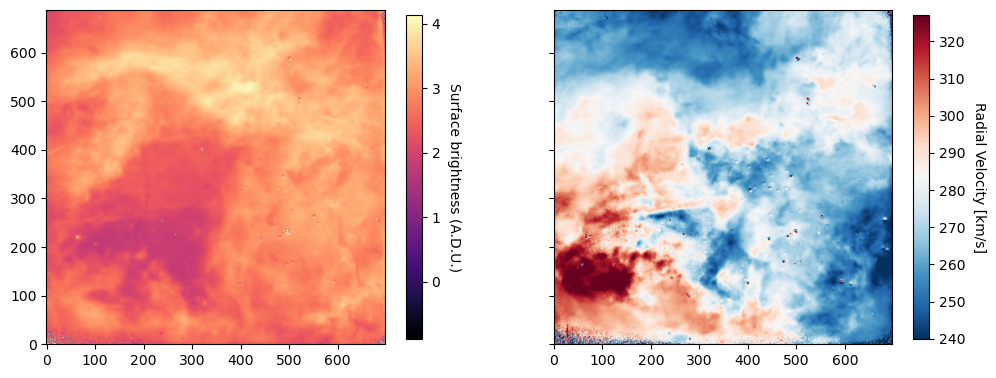

In [13]:
import matplotlib.pyplot as plt

fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv,vmin = 240, vmax=327,**imshow_kwds)
#im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("Radial Velocity [km/s]", rotation=270, labelpad=15)
im = axx.imshow(np.log10(sb), **imshow_kwds2)
#im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("Surface brightness (A.D.U.)", rotation=270, labelpad=15)
#fig.suptitle(plot_label, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

C:\Users\javas\AppData\Local\Temp\ipykernel_43332\943184178.py:15: RuntimeWarning: invalid value encountered in log10
  im = axx.imshow(np.log10(sb), **imshow_kwds2)


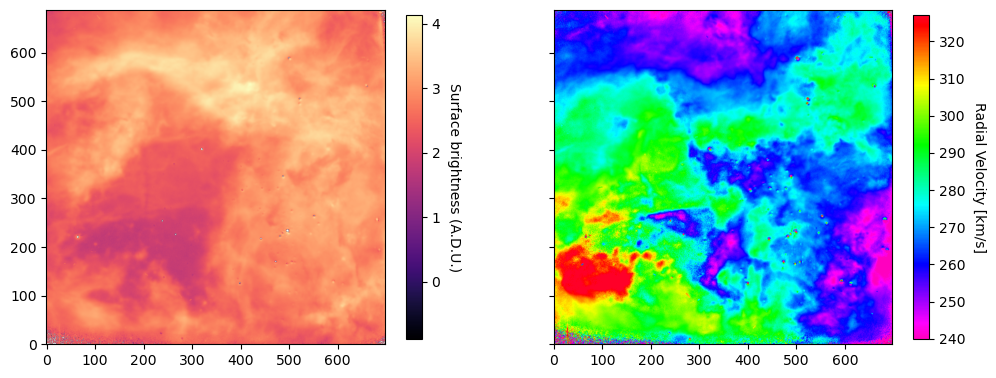

In [14]:
import matplotlib.pyplot as plt

fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="gist_rainbow_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv,vmin = 240, vmax=327,**imshow_kwds)
#im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("Radial Velocity [km/s]", rotation=270, labelpad=15)
im = axx.imshow(np.log10(sb), **imshow_kwds2)
#im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("Surface brightness (A.D.U.)", rotation=270, labelpad=15)
#fig.suptitle(plot_label, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

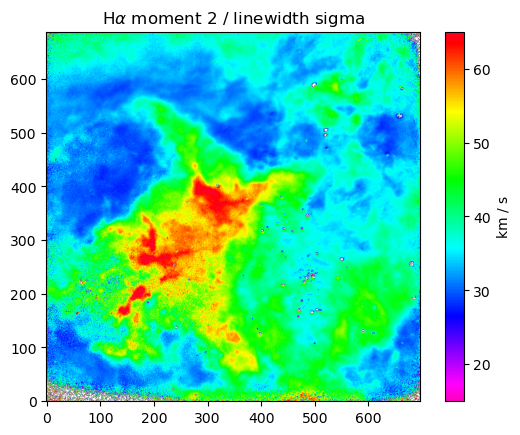

In [15]:

plt.imshow(moment2.value, vmin=15, vmax=65, origin="lower",  cmap="gist_rainbow_r")
plt.colorbar(label=str(moment2.unit))
plt.title(r"H$\alpha$ moment 2 / linewidth sigma")
plt.show()